In [1]:
!pip install --upgrade mysql-connector-python



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [3]:
pip install mysql.connector

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
def make_connection_with_db():
    import mysql.connector

    connection_mydb = mysql.connector.connect(
    host='localhost',
    port=3360,
    user='root',
    password='',
    database='wp_ecommerce')

    cursor = connection_mydb.cursor(dictionary=True)
    return connection_mydb, cursor

In [5]:
def get_customers_by_country():
    _,cursor = make_connection_with_db()

    sql = '''SELECT country, count(customer_id) as count_by_country
            FROM wp_wc_customer_lookup
            group by country'''

    cursor.execute(sql)

    customers_results = cursor.fetchall()

    df = pd.DataFrame(columns=['country','count_by_country'])

    for customer in customers_results:
        obj = {
            "country":[customer['country']],
            "count_by_country":[customer['count_by_country']]
        }

        df_obj = pd.DataFrame(obj)
        df = pd.concat([df, df_obj], ignore_index=True)
    return df

In [6]:
df_customers_countries = get_customers_by_country()

df_customers_countries

,country,count_by_country
0,AE,209
1,BH,218
2,JO,187
3,KW,188
4,SA,179


In [7]:
def show_customers_by_countries_bars():
    df_customers_countries= get_customers_by_country()

    x = df_customers_countries['country']

    y = df_customers_countries['count_by_country']

    plt.xlabel('Country')
    plt.ylabel('Count')

    plt.title('Customers per Countries')
    colors=[]

    for i in range(len(x)):
        colors.append([np.random.rand(), np.random.rand(),np.random.rand()])

        plt.text(x=i, y=y[i], s=y[i])
    plt.bar(x,y, color=colors)

    plt.show()

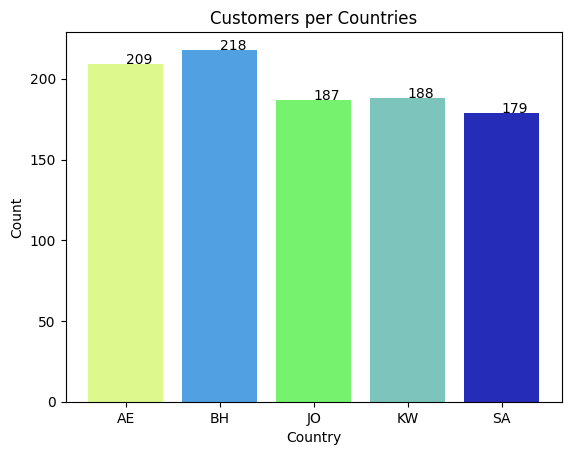

In [8]:
show_customers_by_countries_bars()

In [9]:
def show_customers_by_countries_pie():
    df_customers_countries = get_customers_by_country()

    plt.pie(df_customers_countries['count_by_country'],
    labels = df_customers_countries['country'],
    autopct='%1.1f%%')

    plt.title('Coustomers per Countries')
    plt.show()

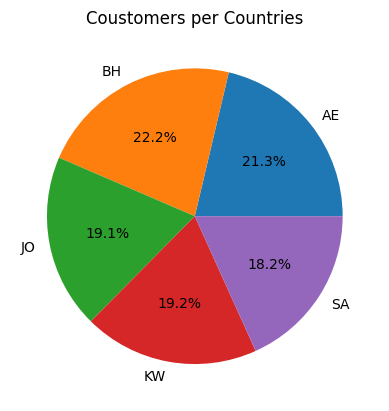

In [10]:
show_customers_by_countries_pie()